In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Загрузка данных из банка России

In [2]:
uploaded = files.upload()

Saving RC_F07_02_2020_T14_02_2026.xlsx to RC_F07_02_2020_T14_02_2026.xlsx


In [4]:
data = pd.read_excel(open('RC_F07_02_2020_T14_02_2026.xlsx', 'rb'))
data.head(10)

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,nominal,data,curs,cdx
0,1,2026-02-14,77.1944,Доллар США
1,1,2026-02-13,77.1880,Доллар США
2,1,2026-02-12,77.4648,Доллар США
3,1,2026-02-11,77.2091,Доллар США
4,1,2026-02-10,77.6502,Доллар США
5,1,2026-02-07,77.0540,Доллар США
6,1,2026-02-06,76.5523,Доллар США
7,1,2026-02-05,76.9102,Доллар США
8,1,2026-02-04,76.9817,Доллар США
9,1,2026-02-03,77.0223,Доллар США


Посмотрим за сколько лет собраны данные в файле

In [5]:
data['year'] = pd.to_datetime(data['data']).dt.year
years = sorted(data['year'].unique())
years

[np.int32(2020),
 np.int32(2021),
 np.int32(2022),
 np.int32(2023),
 np.int32(2024),
 np.int32(2025),
 np.int32(2026)]

In [6]:
data['data'] = pd.to_datetime(data['data'], dayfirst=True)
data.head(10)

,nominal,data,curs,cdx,year
0,1,2026-02-14,77.1944,Доллар США,2026
1,1,2026-02-13,77.1880,Доллар США,2026
2,1,2026-02-12,77.4648,Доллар США,2026
3,1,2026-02-11,77.2091,Доллар США,2026
4,1,2026-02-10,77.6502,Доллар США,2026
5,1,2026-02-07,77.0540,Доллар США,2026
6,1,2026-02-06,76.5523,Доллар США,2026
7,1,2026-02-05,76.9102,Доллар США,2026
8,1,2026-02-04,76.9817,Доллар США,2026
9,1,2026-02-03,77.0223,Доллар США,2026


Выведем диаграмму со всеми значениями курса за весь период

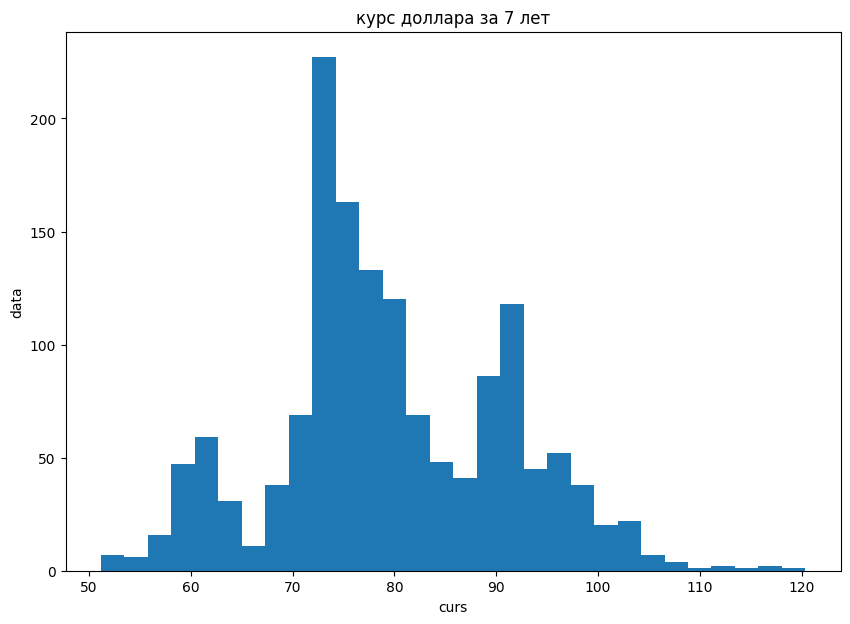

In [7]:
plt.figure(figsize=(10,7))
plt.hist(data['curs'], bins=30)
plt.xlabel('curs')
plt.ylabel('data')
plt.title('курс доллара за 7 лет')
plt.show()

Также выведем отдельно значения по годам

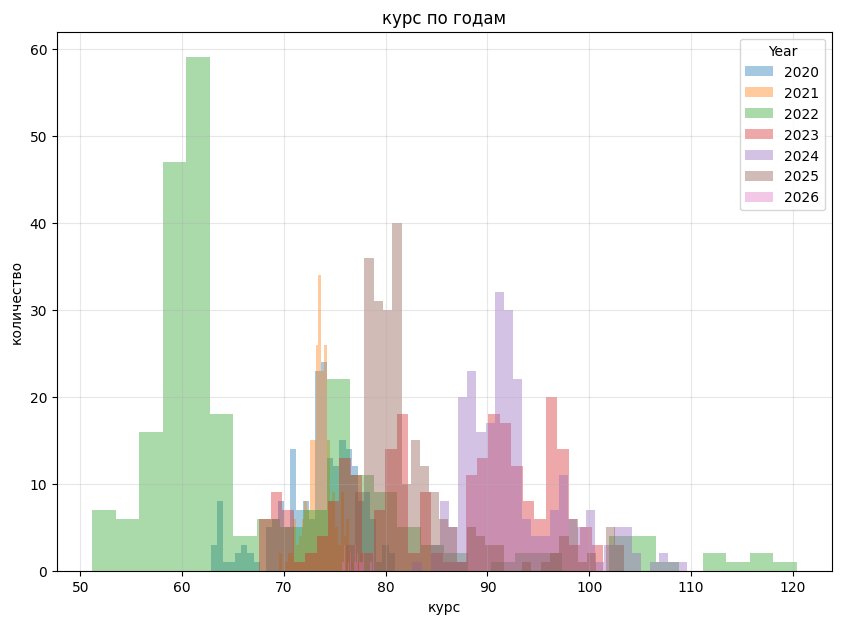

In [8]:
plt.figure(figsize=(10,7))

for year in years:
    year_data = data[data['year'] == year]['curs']
    plt.hist(year_data, bins=30, alpha=0.4, label=str(year))

plt.xlabel('курс')
plt.ylabel('количество')
plt.title('курс по годам')
plt.legend(title='Year')
plt.grid(alpha=0.3)
plt.show()

Разделим данные на квартили для обнаружения выбросов

In [10]:
q1 = data['curs'].quantile(0.25)
q3 = data['curs'].quantile(0.75)
q1, q3

(np.float64(73.2654), np.float64(88.74705))

In [11]:
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
lower_bound, upper_bound

(np.float64(50.042925), np.float64(111.969525))

Удалим выбросы

In [12]:
cleaned_data = data[(data['curs'] >= lower_bound) & (data['curs'] <= upper_bound)]
cleaned_data

,nominal,data,curs,cdx,year
0,1,2026-02-14,77.1944,Доллар США,2026
1,1,2026-02-13,77.1880,Доллар США,2026
2,1,2026-02-12,77.4648,Доллар США,2026
3,1,2026-02-11,77.2091,Доллар США,2026
4,1,2026-02-10,77.6502,Доллар США,2026
...,...,...,...,...,...
1479,1,2020-02-13,63.0470,Доллар США,2020
1480,1,2020-02-12,63.9490,Доллар США,2020
1481,1,2020-02-11,63.7708,Доллар США,2020
1482,1,2020-02-08,63.4720,Доллар США,2020


Для prophet установим требуемые значения столбцов

In [13]:
df = cleaned_data[['data', 'curs']].copy()
df = df.rename(columns={'data': 'ds', 'curs': 'y'})
df

,ds,y
0,2026-02-14,77.1944
1,2026-02-13,77.1880
2,2026-02-12,77.4648
3,2026-02-11,77.2091
4,2026-02-10,77.6502
...,...,...
1479,2020-02-13,63.0470
1480,2020-02-12,63.9490
1481,2020-02-11,63.7708
1482,2020-02-08,63.4720


Импортируем библиотеку и создадим модель с необходимыми параметрами: так как у нас данные только по рабочим дням, отключаем дневную сезонность.выбрана аддитивная сезонность, потому что амплитуда сезонных колебаний курса доллара относительно стабильна во времени и не зависит от общего уровня тренда. увеличим changepoint_prior_scale для гибкости тренда и для учета годовых и недельных циклов также увеличим seasonality_prior_scale

In [14]:
from prophet import Prophet
model = Prophet(daily_seasonality=False,
                yearly_seasonality=True,
                weekly_seasonality=True,
                seasonality_mode='additive',
                changepoint_prior_scale=0.08,
                changepoint_range=0.9,
                n_changepoints=25,
                seasonality_prior_scale=10.0,
                holidays_prior_scale=10.0,
                interval_width=0.95)
model

Добавим российские праздники в модель

In [15]:
model.add_country_holidays(country_name='RU')

Обучим модель

In [16]:
model.fit(df)

Создадим ближайшие две недели

In [17]:
future = model.make_future_dataframe(periods=14)
future.tail(14)

,ds
1480,2026-02-15
1481,2026-02-16
1482,2026-02-17
1483,2026-02-18
1484,2026-02-19
1485,2026-02-20
1486,2026-02-21
1487,2026-02-22
1488,2026-02-23
1489,2026-02-24


Так как банк загружает данные только по будням отредактируем две недели, убрав выходные дни

In [18]:
future_filtered = future.copy()
future_filtered['weekday'] = future_filtered ['ds'].dt.weekday
future_filtered = future_filtered [future_filtered ['weekday'] < 5]
future_filtered = future_filtered.drop(columns=['weekday'])
future_filtered.tail(10)

,ds
1481,2026-02-16
1482,2026-02-17
1483,2026-02-18
1484,2026-02-19
1485,2026-02-20
1488,2026-02-23
1489,2026-02-24
1490,2026-02-25
1491,2026-02-26
1492,2026-02-27


Запустим прогноз на ближайшие две недели

In [19]:
forecast = model.predict(future_filtered)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
1181,2026-02-16,73.888275,67.799455,79.866323
1182,2026-02-17,76.089058,69.644862,82.886111
1183,2026-02-18,76.071424,69.931934,82.813407
1184,2026-02-19,76.044244,69.670872,82.212523
1185,2026-02-20,76.124124,69.874200,82.140776
1186,2026-02-23,76.068967,69.666790,82.039979
1187,2026-02-24,76.508143,69.945982,82.838706
1188,2026-02-25,76.648067,69.712030,83.470645
1189,2026-02-26,76.778597,70.424525,82.939775
1190,2026-02-27,77.013144,70.336031,83.284132


Визуализируем результаты прогнозироавния

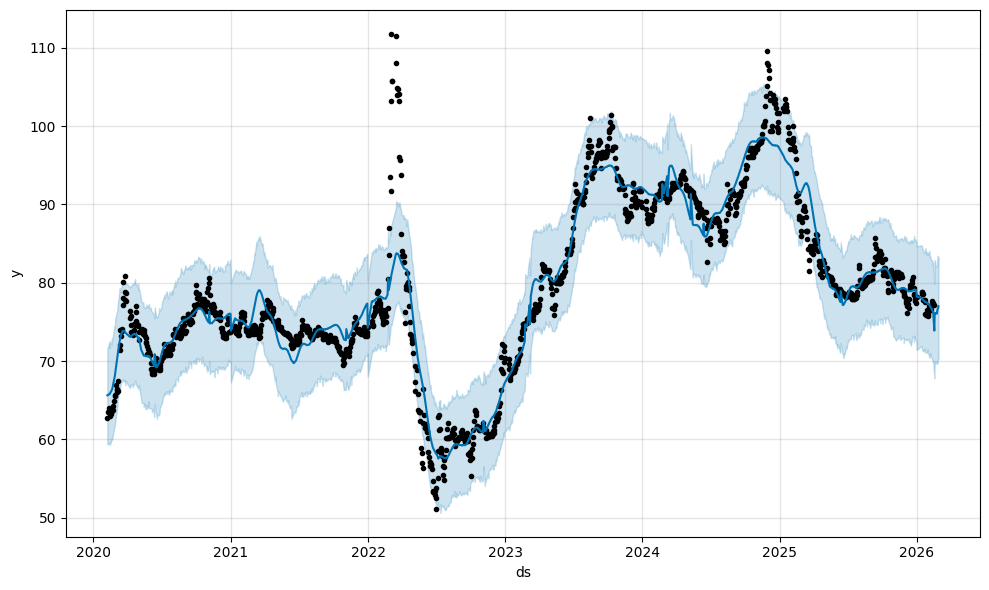

In [20]:
model.plot(forecast);

Визуализируем составляющие компоненты прогноза

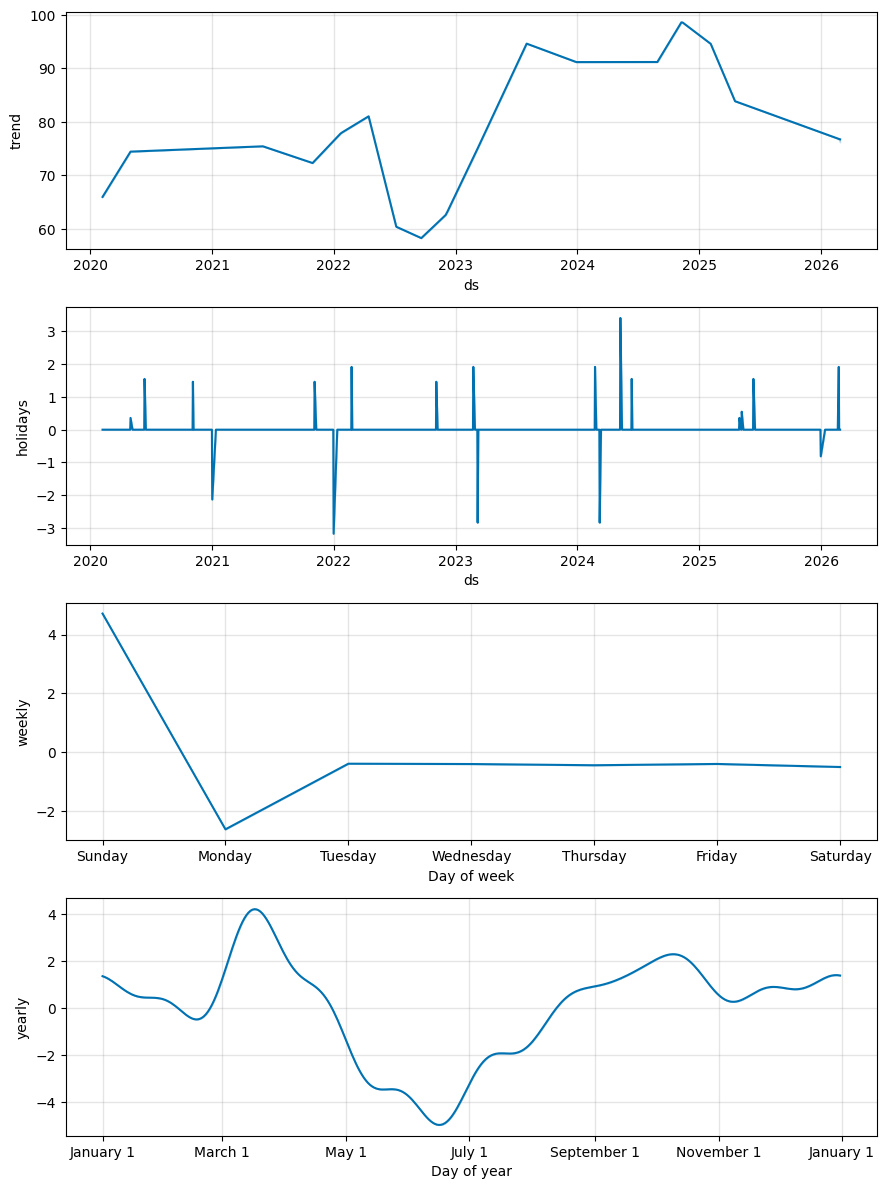

In [21]:
model.plot_components(forecast);